# Setting up a latent function Gaussian Process for H(z)

In [1]:
# import set 
using Turing
using Distances
using LinearAlgebra
using LimberJack
using Interpolations
using GaussianProcess
using Plots
using QuadGK
using BlockDiagonals
using CSV
using DataFrames
using PrettyTables
import LimberJack.TkEisHu
using NumericalIntegration

### Collate data

In [ ]:
# hz data
function data_hz()
    z = [
        0.07, 0.09, 0.12, 0.17, 0.179, 0.199, 0.2,
        0.27, 0.28, 0.352, 0.38, 0.3802, 0.4,
        0.4004, 0.4247, 0.44, 0.4497, 0.47, 0.4783,
        0.48, 0.51, 0.593, 0.6, 0.61, 0.68, 0.73,
        0.781, 0.875, 0.88, 0.9, 1.037, 1.3,
        1.363, 1.43, 1.53, 1.75, 1.965
    ]

    data = [
        69.0, 69.0, 68.6, 83.0, 75.0, 75.0, 72.9,
        77.0, 88.8, 83.0, 81.5, 83.0, 95.0, 77.0,
        87.1, 82.6, 92.8, 89.0, 80.9, 97.0, 90.4,
        104.0, 87.9, 97.3, 92.0, 97.3, 105.0,
        125.0, 90.0, 117.0, 154.0, 168.0, 160.0,
        177.0, 140.0, 202.0, 186.5
    ]

    err = [
        19.6, 12.0, 26.2, 8.0, 4.0, 5.0, 29.6,
        14.0, 36.6, 14.0, 1.9, 13.5, 17.0, 10.2,
        11.2, 7.8, 12.9, 23.0, 9.0, 62.0, 1.9,
        13.0, 6.1, 2.1, 8.0, 7.0, 12.0, 17.0,
        40.0, 23.0, 20.0, 17.0, 33.6, 18.0,
        14.0, 40.0, 50.4
    ]

    cov = zeros(length(z), length(z))
    for i in 1:length(z)
        cov[i, i] = err[i]^2
    end

    return (
        data_name = "data_hz",
        z = z,
        data = data,
        err = err,
        cov = cov
    )
end

# fs8 data
function data_fs8()

z  = [0.3, 0.51, 0.71, 0.92, 1.32, 1.49]

data  = [0.37784, 0.515897, 0.48384, 0.422208, 0.37468, 0.435]

fs8_upper = [0.4723, 0.572693, 0.539136, 0.470586, 0.418064, 0.48]
fs8_lower = [0.28338, 0.449635, 0.428544, 0.378228, 0.343128, 0.39]
err_up = fs8_upper .- data
err_low = data .- fs8_lower
err = (fs8_upper .- fs8_lower) ./ 2

cov = zeros(length(z), length(z))
    for i in 1:length(z)
        cov[i, i] = err[i]^2
    end
    
    return (data_name = "data_fs8", z = z, data = data, err = err, cov = cov)
end

In [ ]:
# fs8 data
function data_combtracer_fs8()

z  = [0.026]
data  = [0.412]
err = 0.018

cov = [err^2;;]

    return (data_name = "data_combtracer_fs8", z = z, data = data, err = err, cov = cov)
end

datatracerfs8 = data_combtracer_fs8();

In [ ]:
# Load data
supernovae_raw = CSV.read("DES_Dovekie_HD.csv", DataFrame);
# Find indices that satisfy the condition
keep_idx = findall(supernovae_raw.MUERR .< 1);
# Filter the dataframe
supernovae = supernovae_raw[keep_idx, :];
# Load covariance matrix
supernovae_cov_df = CSV.read("STAT+SYS_dovekie.csv", DataFrame);
supernovae_cov = Matrix(supernovae_cov_df);
# Filter covariance matrix (rows AND columns)
sup_cov_filt = supernovae_cov[keep_idx, keep_idx];

function data_mu()

    z = supernovae[!,"zHD"][1:30:end]
    z_hel = supernovae[!,"zHEL"][1:30:end]
    data = supernovae[!,"MU"][1:30:end]

    cov = Symmetric(sup_cov_filt[1:30:end, 1:30:end])

    err = sqrt.(diag(cov))

    return (data_name = "data_mu", z = z, z_hel = z_hel, data = data, err = err, cov = cov)

end

datamu = data_mu();

In [2]:
function data_DESI()
    # DESI data
    z1 = [0.3, 0.51, 0.71, 0.92, 1.32, 1.49]
    z = repeat(z1, inner = 4)
    data_dvrd = [7.788174, 12.514437, 15.675560, 19.676985, 23.861806, 25.708520]
    data_dhdm = [3.053800, 1.637266, 1.165867, 0.844996, 0.470709, 0.426508] 
    data_fss8 = [0.377174, 0.513635, 0.483623, 0.422164, 0.376715, 0.434858]
    data_m = [-0.031370, 0.027840, 0.046650, -0.024690, 0.059960, 0.064550]
    
    data = 
    [7.788174, 3.053800, 0.377174, -0.031370,    # BGS (z=0.30)
    12.514437, 1.637266, 0.513635, 0.027840, # LRG1 (z=0.51)
    15.675560, 1.165867, 0.483623, 0.046650,  # LRG2 (z=0.71)
    19.676985, 0.844996, 0.422164, -0.024690, # LRG3 (z=0.92)
    23.861806, 0.470709, 0.376715, 0.059960,  # ELG2 (z=1.32)
    25.708520, 0.426508, 0.434858, 0.064550]   # QSO (z=1.49)

    # Full 18x18 Covariance Matrix for DESI 2024 Year 1 
    # Variables: [DV/rd, DH/DM, fσs8] per redshift bin
    # Source: arXiv:2411.12021 Appendix A
    C_total = zeros(24, 24);

    # BGS z=0.30
    C_total[1:4, 1:4] = [1314.664401  -142.669742   109.427163  -217.509715;
                -142.669742   829.170940  -158.101737   -61.084426;
                 109.427163  -158.101737    88.510877    -2.272457;
                -217.509715   -61.084426    -2.272457   279.702360] .* 1e-4

    # LRG1, zeff = 0.51
    C_total[5:8, 5:8] = [541.309833   48.425593    -4.652853   -37.707751;
                        48.425593   97.249820   -34.923265   -14.418597;
                        -4.652853  -34.923265    41.295470    15.405508;
                        -37.707751  -14.418597    15.405508    48.918910] .* 1e-4

    # LRG2, zeff = 0.71
    C_total[9:12, 9:12] = [762.457717   39.781004    -1.896006   -62.812849;
                            39.781004   36.344098   -17.341350    -8.333900;
                            -1.896006  -17.341350    28.119682     8.865225;
                        -62.812849   -8.333900     8.865225    47.624520] .* 1e-4

    # LRG3, zeff = 0.92
    C_total[13:16, 13:16] = [847.499793   26.038900     3.257324   -37.016091;
                            26.038900   16.251088   -10.044074    -3.698790;
                            3.257324  -10.044074    22.370314     6.467510;
                            -37.016091   -3.698790     6.467510    34.883220] .* 1e-4

    # ELG2, zeff = 1.32
    C_total[17:20, 17:20] = [2342.506886   26.159601    13.521001   -95.336060;
                                26.159601   10.309303    -6.654663    -5.183903;
                                13.521001   -6.654663    13.997473     9.109619;
                            -95.336060   -5.183903     9.109619    43.575710] .* 1e-4

    # QSO, zeff = 1.49
    C_total[21:24, 21:24] = [3013.788566   -2.205101    36.332110   -98.167826;
                                -2.205101    5.845806    -6.747133    -1.913326;
                                36.332110   -6.747133    19.785658     5.357546;
                            -98.167826   -1.913326     5.357546    26.266260] .* 1e-4

    
    cov = C_total
    
    err_arr = sqrt.(diag(cov))
    err_dvrd = err_arr[1:4:end]
    err_dhdm = err_arr[2:4:end]
    err_fss8 = err_arr[3:4:end]
    err_m = err_arr[4:4:end]

    return(data_name = "data_DESI", z1 = z1, z = z, data = data, data_dvrd = data_dvrd, data_dhdm = data_dhdm, data_fss8 = data_fss8, data_m = data_m, err_dvrd = err_dvrd, err_dhdm = err_dhdm, err_fss8 = err_fss8, err_m = err_m, cov = cov)
end

data_DESI (generic function with 1 method)

In [ ]:
# function data_DESI()
#     # DESI data
#     z1 = [0.3, 0.51, 0.71, 0.92, 1.32, 1.49]
#     z = repeat(z1, inner = 3)
#     data_dvrd = [7.788174, 12.514437, 15.675560, 19.676985, 23.861806, 25.708520]
#     data_dhdm = [3.053800, 1.637266, 1.165867, 0.844996, 0.470709, 0.426508] 
#     data_fss8 = [0.377174, 0.513635, 0.483623, 0.422164, 0.376715, 0.434858]
    
#     data = 
#     [7.788174, 3.053800, 0.377174,   # BGS (z=0.30)
#     12.514437, 1.637266, 0.513635, # LRG1 (z=0.51)
#     15.675560, 1.165867, 0.483623,  # LRG2 (z=0.71)
#     19.676985, 0.844996, 0.422164, # LRG3 (z=0.92)
#     23.861806, 0.470709, 0.376715,  # ELG2 (z=1.32)
#     25.708520, 0.426508, 0.434858]   # QSO (z=1.49)

#     # Full 18x18 Covariance Matrix for DESI 2024 Year 1 
#     # Variables: [DV/rd, DH/DM, fσs8] per redshift bin
#     # Source: arXiv:2411.12021 Appendix A
#     C_total = zeros(18, 18);

#     # BGS z=0.30
#     C_total[1:3, 1:3] = 1e-4 * [
#         1314.664401 -142.669742  109.427163;
#         -142.669742  829.170940 -158.101737;
#         109.427163 -158.101737   88.510877
#     ]

#     # LRG1 z=0.51
#     C_total[4:6, 4:6] = 1e-4 * [
#         541.309833   48.425593   -4.652853;
#         48.425593   97.249820  -34.923265;
#         -4.652853  -34.923265   41.295470
#     ]

#     # LRG2 z=0.71
#     C_total[7:9, 7:9] = 1e-4 * [
#         762.457717   39.781004   -1.896006;
#         39.781004   36.344098  -17.341350;
#         -1.896006  -17.341350   28.119682
#     ]

#     # LRG3 z=0.92
#     C_total[10:12, 10:12] = 1e-4 * [
#         847.499793   26.038900    3.257324;
#         26.038900   16.251088  -10.044074;
#         3.257324  -10.044074   22.370314
#     ]

#     # ELG2 z=1.32
#     C_total[13:15, 13:15] = 1e-4 * [
#     2342.506886   26.159601   13.521001;
#         26.159601   10.309303   -6.654663;
#         13.521001   -6.654663   13.997473
#     ]

#     # QSO z=1.49
#     C_total[16:18, 16:18] = 1e-4 * [
#     3013.788566   -2.205101   36.332110;
#         -2.205101    5.845806   -6.747133;
#         36.332110   -6.747133   19.785658
#     ]

    
#     cov = C_total
    
#     err_arr = sqrt.(diag(cov))
#     err_dvrd = err_arr[1:3:end]
#     err_dhdm = err_arr[2:3:end]
#     err_fss8 = err_arr[3:3:end]

#     return(data_name = "data_DESI", z1 = z1, z = z, data = data, data_dvrd = data_dvrd, data_dhdm = data_dhdm, data_fss8 = data_fss8, err_dvrd = err_dvrd, err_dhdm = err_dhdm, err_fss8 = err_fss8, cov = cov)
# end

In [3]:
dataDESI = data_DESI();

#### Putting data together

In [4]:
# errors
aiso_err = dataDESI.err_dvrd;
aap_err = dataDESI.err_dhdm;
fss8_err = dataDESI.err_fss8;
m_err = dataDESI.err_m;


In [ ]:
# cosmo_fid: Table 2 of https://arxiv.org/pdf/1807.06209, TT,TE,EE+lowE 68% limits
# kvector, rd, zarr, Ωm, Ωb, Ωc, σ8, h0, ez
rd_red = 147.05;

z_integ1 = range(0.0, 2.5, length=300);

klog = range(log(0.0001), stop=log(100.0), length=300);
k_integ = exp.(klog)
# k_integ = range(0.01, 0.15, length=300);
cosmo = Cosmology(Ωm=0.3153, Ωb=0.049, h=0.6736, σ8=0.8111, ns=0.9649)
cosmo_fid = Cosmology(Ωm=0.3166, Ωb=0.049, h=0.6727, σ8=0.8120, ns=0.9649)

r_star = 144.39;  # Mpc
r_d_fid = 147.05
kpiv = 0.03

ez_test = Ez(cosmo, z_integ1);
ez_fid_test = Ez(cosmo_fid, z_integ1);

# z_CMB = logrange(1.0, 1100.0, length=1000) .- 1.0;
# ez_CMB_test = Ez(cosmo_fid, z_CMB);
# println(cosmo_fid.cpar.Ωm, cosmo_fid.cpar.Ωb, cosmo_fid.cpar.Ωc, cosmo_fid.cpar.σ8, cosmo_fid.cpar.h)
# pk_fiducial = EH98(k_integ, r_d_fid, z_integ1, cosmo_fid.cpar.Ωm, cosmo_fid.cpar.Ωb, cosmo_fid.cpar.Ωc, cosmo_fid.cpar.σ8, cosmo_fid.cpar.h, ez_fid_test);
# println(pk_fiducial[200:215])

0.31660.0490.26760.8120.6727


300-element Vector{Float64}:
 3.309283956872013e-19
 3.4296630388374843e-19
 3.5543830487583353e-19
 3.6836015781141525e-19
 3.8174823747268646e-19
 3.9561956212689654e-19
 4.099916819797997e-19
 4.2488288200950102e-19
 4.403121953669827e-19
 4.562992756794256e-19
 ⋮
 3.966375789067681e-23
 3.4940462726823916e-23
 3.077501237246691e-23
 2.710214958503803e-23
 2.386417447734368e-23
 2.101005781903583e-23
 1.8494689302205787e-23
 1.627822774132686e-23
 1.432545698889404e-23

In [ ]:
zdf = DataFrame(
    z = z_integ1
)
CSV.write("zinteg1.csv", zdf)

aisodf = DataFrame(
    data = dataDESI.data_dvrd,
    z = dataDESI.z1,
    err = aiso_err
)
aisolcdm = DataFrame(
    LCDM = a_iso(z_integ1, cosmo1.cpar.h, rd_red, ez_test)
)
CSV.write("aiso_data.csv", aisodf)
CSV.write("aiso_lcdm.csv", aisolcdm)

mudf = DataFrame(
    data = datamu.data,
    z = datamu.z,
    err = datamu.err
)
mulcdm  = DataFrame(
    LCDM = mu(z_integ1, z_integ1, cosmo1.cpar.h, ez_test)
)
CSV.write("mu_data.csv", mudf)
CSV.write("mu_lcdm.csv", mulcdm)

fs8df = DataFrame(
    data = [datatracerfs8.data;datafs8.data],
    z = [datatracerfs8.z;datafs8.z],
    err = fs8_err
)
CSV.write("fs8_data.csv", fs8df)


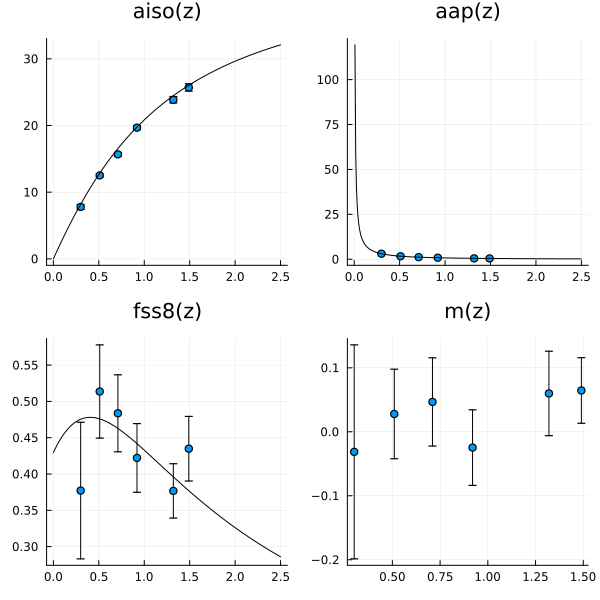

In [49]:
# p0 = plot(datahz.z, datahz.data, yerr=hz_err, seriestype=:scatter,title="H(z)", legend=false)
p1 = plot(dataDESI.z1, dataDESI.data_dvrd, yerr=aiso_err, seriestype=:scatter,title="aiso(z)", legend=false)
p2 = plot(dataDESI.z1, dataDESI.data_dhdm, yerr=aap_err, seriestype=:scatter, title="aap(z)", legend=false)
p3 = plot(dataDESI.z1, dataDESI.data_fss8, yerr=fss8_err, seriestype=:scatter, title="fss8(z)", legend=false)
# p4 = plot(log10.(datamu.z), datamu.data, yerr=mu_err, seriestype=:scatter, title="mu(z)", legend=false)
# p5 = plot(dataCMB.z, dataCMB.data, yerr=CMB_err, seriestype=:scatter, title="CMB", legend=false)
p6 = plot(dataDESI.z1, dataDESI.data_m, yerr=m_err, seriestype=:scatter, title="m(z)", legend=false)

# plot!(p0, z_integ1, hz_from_ez(z_integ1, cosmo_fid.cpar.h, ez_fid_test), color=:black)
plot!(p1, z_integ1, a_iso(z_integ1, cosmo_fid.cpar.h, rd_red, ez_fid_test), color=:black)
plot!(p2, z_integ1, a_ap(z_integ1, cosmo_fid.cpar.h, ez_fid_test), color=:black)
plot!(p3, z_integ1, fss8_from_ez(z_integ1, z_integ1, ez_fid_test, k_integ, cosmo_fid.cpar.Ωm, cosmo_fid.cpar.σ8, cosmo_fid.cpar.h, r_d_fid, r_d_fid, cosmo_fid), color=:black)
# plot!(p4, log10.(z_integ1), mu(z_integ1, z_integ1, cosmo_fid.cpar.h, ez_fid_test), color=:black)
# plot!(p5, z_CMB[990:end], theta2(z_CMB, r_star, cosmo_fid.cpar.h, ez_CMB_test)[990:end], color=:black)
# plot!(p6, z_integ1, m_shapefit(z_integ1, z_integ1, cosmo_fid.cpar.Ωm, cosmo_fid.cpar.σ8, cosmo_fid.cpar.h, cosmo, cosmo_fid, ez_test, ez_fid_test, k_integ, kpiv), color=:black)

plot(p1, p2, p3, p6, layout=(2,2), size=(600,600))

In [ ]:
# data_obs = [datahz.data; datatracerfs8.data; dataDESI.data];
# z_obs = [datahz.z; datatracerfs8.z; dataDESI.z];
# covariance_obs = BlockDiagonal([datahz.cov, datatracerfs8.cov, dataDESI.cov]);
data_obs = [datahz.data; datatracerfs8.data; dataDESI.data; datamu.data; dataCMB.data];
z_obs = [datahz.z; datatracerfs8.z; dataDESI.z; datamu.z; dataCMB.z];
covariance_obs = BlockDiagonal([datahz.cov, datatracerfs8.cov, dataDESI.cov, datamu.cov, dataCMB.cov]);

In [ ]:
cov_df = DataFrame(covariance_obs, :auto)
CSV.write("covariance_data.csv", cov_df)